# Clasificación Bioacústica de Especies

Proyecto IA II

Objetivo:
Clasificar especies mediante grabaciones de audio usando Deep Learning y espectrogramas Mel.


In [ ]:
#@title **Librerias y Paquetes**

!pip install kagglehub

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras import layers, models

import kagglehub

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_f6736a1438329933cf2af4cb089b7c12'

In [ ]:
path = kagglehub.competition_download('birdclef-2025')
print(path)

os.listdir(path)

Resuming download from 5193596928 bytes (7160098049 bytes left)...
Resuming download to /root/.cache/kagglehub/competitions/birdclef-2025.archive (5193596928/12353694977) bytes left.


100%|██████████| 11.5G/11.5G [06:32<00:00, 18.2MB/s]

Extracting files...


/root/.cache/kagglehub/competitions/birdclef-2025


['taxonomy.csv',
 'train.csv',
 'recording_location.txt',
 'train_audio',
 'sample_submission.csv',
 'train_soundscapes',
 'test_soundscapes']

Se truncaron las últimas líneas 5000 del resultado de transmisión.
        H93_20230508_110500.ogg
        H18_20230513_022000.ogg
        H03_20230501_165500.ogg
        H06_20230424_125500.ogg
        H17_20230516_180000.ogg
        H74_20230430_063000.ogg
        H93_20230503_085500.ogg
        O203_20230516_113000.ogg
        H91_20230429_021500.ogg
        H92_20230509_225000.ogg
        H21_20230518_153500.ogg
        H90_20230510_021000.ogg
        H28_20230502_192500.ogg
        H29_20230521_150000.ogg
        H20_20230424_024000.ogg
        H04_20230423_130500.ogg
        H24_20230502_102500.ogg
        H79_20230503_204500.ogg
        H04_20230424_171000.ogg
        H94_20230502_071500.ogg
        H93_20230518_163000.ogg
        H63_20230506_131000.ogg
        H65_20230509_073000.ogg
        H91_20230428_134500.ogg
        H08_20230421_030000.ogg
        H17_20230504_132500.ogg
        O203_20230427_005500.ogg
        H29_20230505_103500.ogg
        H12_20230511_061500.ogg
   

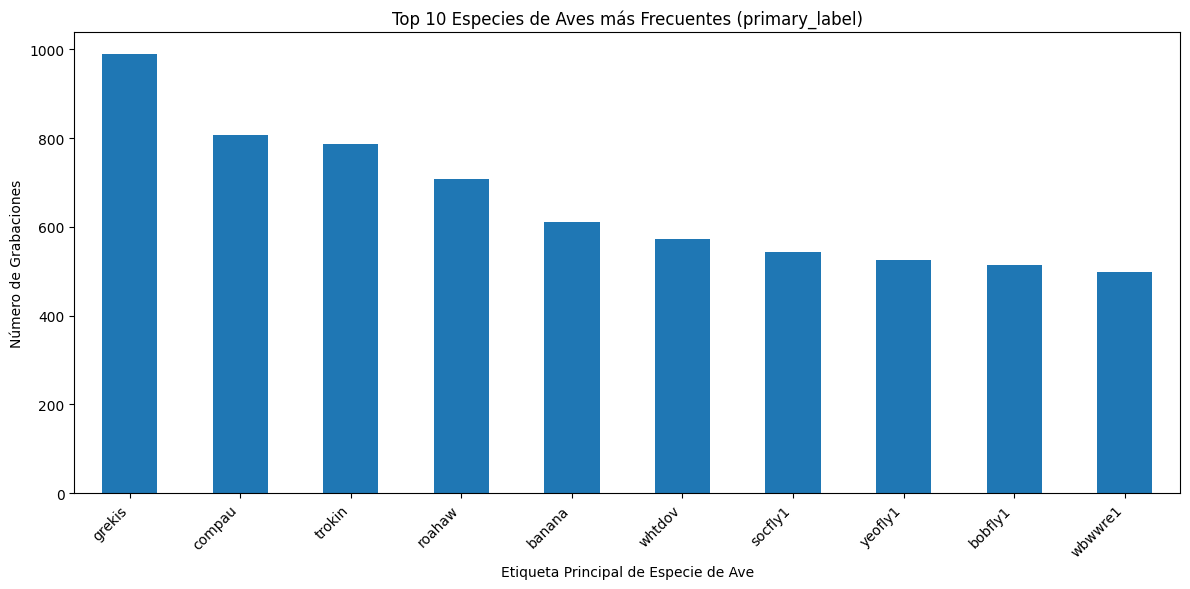

In [ ]:
#@title **Exploración Datos Entrenamiento**

# 1. Listar carpetas y archivos
print("\n--- Archivos y Carpetas en el dataset ---")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

# Cargar el archivo train.csv
train_df_path = os.path.join(path, 'train.csv')
try:
    train_df = pd.read_csv(train_df_path)

    #Nombre de las columnas
    print("\n--- Columnas de train.csv ---")
    print(train_df.columns.tolist())

    # Mostrar cantidad de especies únicas (primary_label)
    unique_species = train_df['primary_label'].nunique()
    print(f"\n--- Cantidad de especies únicas: {unique_species} ---")

except FileNotFoundError:
    print(f"Error: El archivo train.csv no se encontró en la ruta: {train_df_path}")
except Exception as e:
    print(f"Ocurrió un error al procesar train.csv: {e}")

In [ ]:
#@title **Exploración de un ejemplo**
print("\n--- Buscando información de un audio específico en train.csv ---\n")

# Asegurarse de que train_df esté cargado
if 'train_df' not in locals():
    print("Cargando train_df, ya que no se encontró en el entorno.")
    try:
        # Asume que 'path' ya está definido desde la descarga de Kaggle
        if 'path' not in locals():
            import kagglehub
            path = kagglehub.competition_download('birdclef-2025')
        train_df_path = os.path.join(path, 'train.csv')
        train_df = pd.read_csv(train_df_path)
        print("train_df cargado con éxito.")
    except Exception as e:
        print(f"Error al cargar train_df: {e}. No se puede buscar la información.\n")
        train_df = pd.DataFrame()

if not train_df.empty:
    target_filename = '1139490/CSA36385.ogg'
    audio_info = train_df[train_df['filename'] == target_filename]

    if not audio_info.empty:
        print(f"Información encontrada para '{target_filename}':\n")
        # Imprimir todas las columnas de la fila encontrada
        # Usamos .iloc[0] para obtener la primera (y única) fila como una Serie
        # y .to_string() para asegurar que se muestren todas las columnas sin truncar
        print(audio_info.iloc[0].to_string())
    else:
        print(f"No se encontró información para el archivo '{target_filename}' en train.csv.")
else:
    print("El DataFrame 'train_df' está vacío. No se puede buscar la información.")


--- Buscando información de un audio específico en train.csv ---

Información encontrada para '1139490/CSA36385.ogg':

primary_label                                                 1139490
secondary_labels                                                 ['']
type                                                             ['']
filename                                         1139490/CSA36385.ogg
collection                                                        CSA
rating                                                            0.0
url                 http://colecciones.humboldt.org.co/rec/sonidos...
latitude                                                       7.3206
longitude                                                    -73.7128
scientific_name                                  Ragoniella pulchella
common_name                                      Ragoniella pulchella
author                                              Fabio A. Sarria-S
license                                 


--- Analizando un audio del subconjunto ---
Audio seleccionado para análisis: trokin/XC944358.ogg (Especie: trokin)
Duración del audio: 64.18 segundos
Frecuencia de muestreo (Sample Rate): 32000 Hz


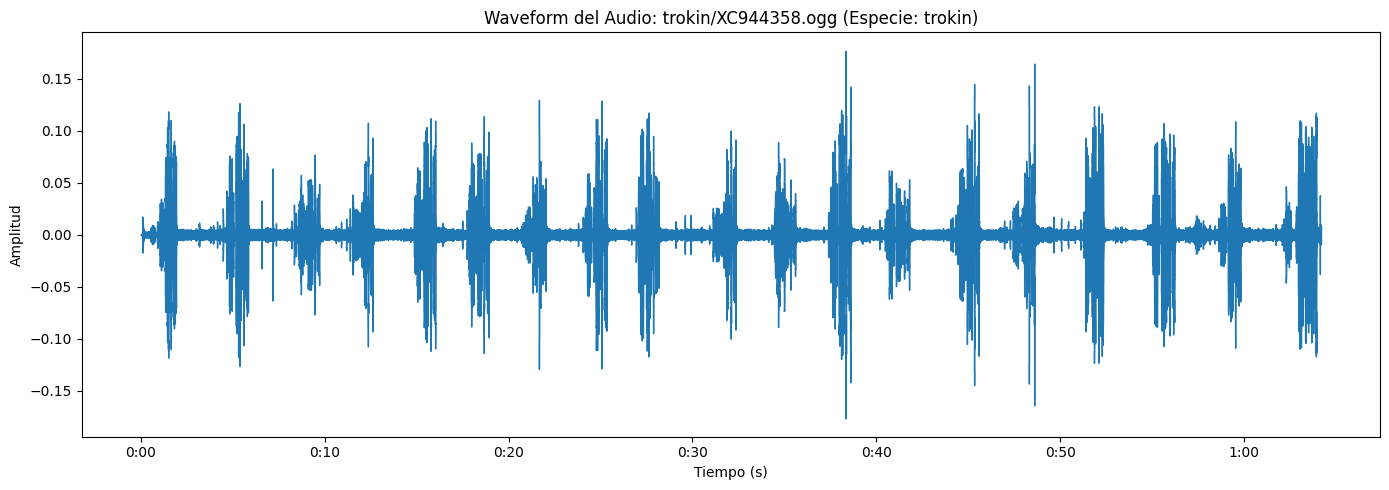

In [ ]:
#@title **Exploración de un ejemplo**

print("\n--- Analizando un audio del subconjunto ---")

# Seleccionar un audio aleatorio del subconjunto
# Es importante asegurarse de que subset_df no esté vacío antes de intentar seleccionar un audio.
if not subset_df.empty:
    random_audio_info = subset_df.sample(n=1, random_state=42).iloc[0]
    audio_filename = random_audio_info['filename']
    primary_label = random_audio_info['primary_label']

    # Construir la ruta completa al archivo de audio
    # El formato del filename es 'bird_code/audio_id.ogg'
    audio_full_path = os.path.join(path, 'train_audio', audio_filename)

    print(f"Audio seleccionado para análisis: {audio_filename} (Especie: {primary_label})")

    try:
        # Cargar el audio usando librosa
        # sr=None para mantener la frecuencia de muestreo original del archivo
        y, sr = librosa.load(audio_full_path, sr=None)

        # Mostrar duración del audio
        duration = librosa.get_duration(y=y, sr=sr)
        print(f"Duración del audio: {duration:.2f} segundos")

        # Mostrar sample rate (frecuencia de muestreo)
        print(f"Frecuencia de muestreo (Sample Rate): {sr} Hz")

        # Graficar la waveform (forma de onda)
        plt.figure(figsize=(14, 5))
        librosa.display.waveshow(y, sr=sr)
        plt.title(f'Waveform del Audio: {audio_filename} (Especie: {primary_label})')
        plt.xlabel('Tiempo (s)')
        plt.ylabel('Amplitud')
        plt.tight_layout()
        plt.show()

    except FileNotFoundError:
        print(f"Error: El archivo de audio no se encontró en la ruta: {audio_full_path}")
    except Exception as e:
        print(f"Ocurrió un error al cargar o procesar el audio: {e}")
else:
    print("El DataFrame 'subset_df' está vacío. No se pueden seleccionar audios para análisis.")

In [ ]:
#@title **Cantidad de audios por nombre científico**

print("\n--- Listando especies y cantidad de audios ---\n")

# Asegurarse de que train_df esté cargado
if 'train_df' not in locals():
    print("Cargando train_df, ya que no se encontró en el entorno.")
    try:
        # Asume que 'path' ya está definido desde la descarga de Kaggle
        if 'path' not in locals():
            import kagglehub
            path = kagglehub.competition_download('birdclef-2025')
        train_df_path = os.path.join(path, 'train.csv')
        train_df = pd.read_csv(train_df_path)
        print("train_df cargado con éxito.")
    except Exception as e:
        print(f"Error al cargar train_df: {e}. No se pueden generar las listas.\n")
        train_df = pd.DataFrame()

if not train_df.empty:
    # 1. Listar especies y cantidad de audios por cada una (scientific_name)
    species_audio_counts = train_df['scientific_name'].value_counts()
    print("**Cantidad de audios por especie:**")
    print(species_audio_counts.to_string())
    print("\n")



--- Listando especies y cantidad de audios ---

**Cantidad de audios por especie:**
scientific_name
Pitangus sulphuratus            990
Nyctidromus albicollis          808
Tyrannus melancholicus          787
Rupornis magnirostris           709
Coereba flaveola                610
Leptotila verreauxi             572
Myiozetetes similis             543
Tolmomyias sulphurescens        525
Megarynchus pitangua            514
Henicorhina leucosticta         499
Vanellus chilensis              487
Camptostoma obsoletum           478
Megascops choliba               470
Herpetotheres cachinnans        467
Tapera naevia                   431
Dendrocygna autumnalis          424
Sicalis flaveola                419
Falco sparverius                409
Setophaga pitiayumi             397
Nyctibius griseus               383
Volatinia jacarina              380
Cantorchilus leucotis           379
Myiodynastes maculatus          377
Aramides cajaneus               365
Ardea alba                      340

In [ ]:
#@title **Subconjunto Datos de Prueba del Modelo**

print("\n--- Creando subconjunto para pruebas rápidas ---")

# Seleccionar las 5 especies con más audios
# La variable top_10_species ya contiene las frecuencias, podemos usar los índices (nombres de especies)
top_5_species_labels = top_10_species.head(5).index.tolist()
print(f"Las 5 especies más frecuentes seleccionadas: {top_5_species_labels}")

# Crear un DataFrame vacío para el subconjunto
subset_df = pd.DataFrame()

# Limitar a máximo 30 audios por especie para cada una de las top 5
for species_label in top_5_species_labels:
    species_data = train_df[train_df['primary_label'] == species_label]
    # Seleccionar hasta 30 audios de cada especie
    limited_species_data = species_data.sample(n=min(30, len(species_data)), random_state=42) # random_state para reproducibilidad
    subset_df = pd.concat([subset_df, limited_species_data])

# Mostrar cuántos audios quedaron por especie en el subconjunto
print("\n--- Cantidad de audios por especie en el subconjunto para pruebas ---")
print(subset_df['primary_label'].value_counts())

print(f"\nTotal de audios en el subconjunto para pruebas: {len(subset_df)}")
print("Subconjunto creado exitosamente (variable: subset_df).")


--- Creando subconjunto para pruebas rápidas ---
Las 5 especies más frecuentes seleccionadas: ['grekis', 'compau', 'trokin', 'roahaw', 'banana']

--- Cantidad de audios por especie en el subconjunto para pruebas ---
primary_label
grekis    30
compau    30
trokin    30
roahaw    30
banana    30
Name: count, dtype: int64

Total de audios en el subconjunto para pruebas: 150
Subconjunto creado exitosamente (variable: subset_df).



--- Generando espectrograma Mel ---


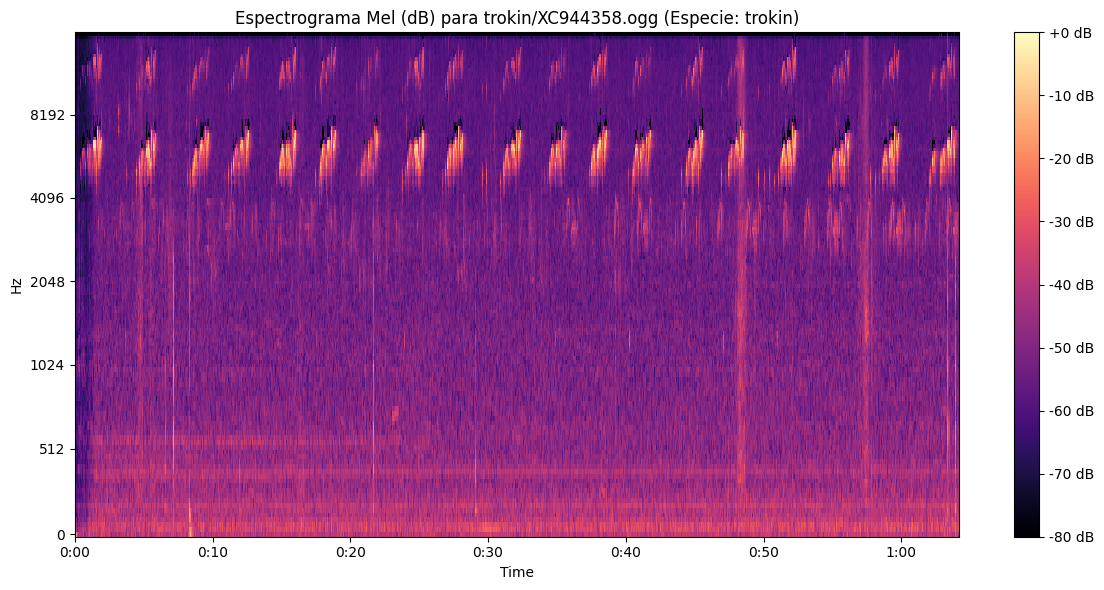

In [ ]:
#@title **Generación de Espectogramas (1 ejemplo, sin normalizar)**
print("\n--- Generando espectrograma Mel ---")

# Asegurarse de que el audio y sample rate del paso anterior estén disponibles
# Usamos las variables 'y' (audio) y 'sr' (sample rate) de la celda anterior.
# Si no se ejecutó la celda anterior o si 'y' y 'sr' no están definidos, se cargará el audio de nuevo.
if 'y' not in locals() or 'sr' not in locals():
    print("Las variables 'y' o 'sr' no están definidas. Cargando un audio aleatorio...")
    if not subset_df.empty:
        random_audio_info = subset_df.sample(n=1, random_state=42).iloc[0]
        audio_filename = random_audio_info['filename']
        primary_label = random_audio_info['primary_label']
        audio_full_path = os.path.join(path, 'train_audio', audio_filename)

        try:
            y, sr = librosa.load(audio_full_path, sr=None)
            print(f"Audio cargado para espectrograma: {audio_filename} (Especie: {primary_label})")
        except Exception as e:
            print(f"Error al cargar audio para espectrograma: {e}")
            y = None # Asegurar que y sea None si hay error
            sr = None # Asegurar que sr sea None si hay error
    else:
        print("El DataFrame 'subset_df' está vacío. No se pueden seleccionar audios para análisis.")
        y = None
        sr = None

if y is not None and sr is not None:
    # 1. Generar el espectrograma Mel
    # n_fft: tamaño de la ventana FFT, hop_length: número de muestras entre tramas consecutivas
    # n_mels: número de bandas Mel a generar
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)

    # 2. Convertir el espectrograma a escala de decibeles
    # librosa.power_to_db convierte un espectrograma de potencia (magnitud al cuadrado) a decibeles.
    S_db = librosa.power_to_db(S, ref=np.max)

    # 3. Visualizar el espectrograma Mel en escala de decibeles
    plt.figure(figsize=(12, 6))
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB') # Agregar una barra de color en decibeles
    plt.title(f'Espectrograma Mel (dB) para {random_audio_info.get('filename', 'Audio Desconocido')} (Especie: {random_audio_info.get('primary_label', 'Desconocida')})')
    plt.tight_layout()
    plt.show()
else:
    print("No se pudo procesar el espectrograma Mel debido a la falta de datos de audio.")


--- Generando espectrogramas Mel para el subconjunto de datos ---
Generación de espectrogramas completada.
Forma de X (espectrogramas): (150, 128, 128) (número_audios, altura_mel, ancho_fotogramas)
Forma de y (etiquetas): (150,)
Los datos están listos en las variables 'X_mels' y 'y_labels'.


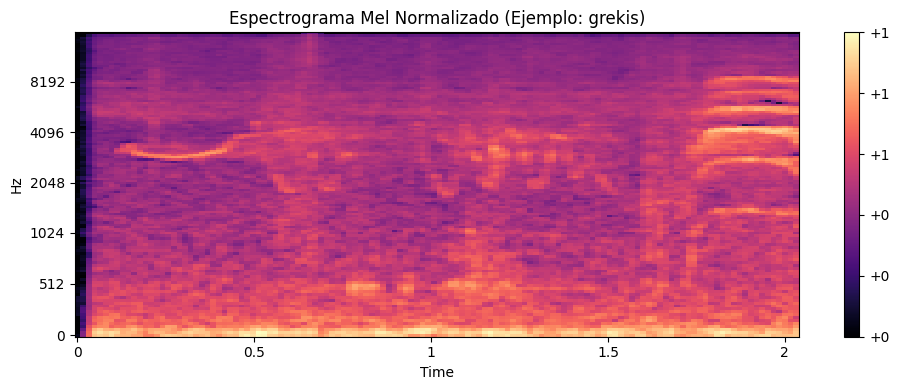

In [ ]:
#@title **Generación de Espectogramas (General)**

print("\n--- Generando espectrogramas Mel para el subconjunto de datos ---")

# Definir parámetros para la generación de espectrogramas Mel
MAX_AUDIO_DURATION_SEC = 5.0  # Limitar a 5 segundos para acelerar pruebas y uniformizar longitud
TARGET_MEL_HEIGHT = 128       # Número de bandas Mel (altura del espectrograma)
TARGET_MEL_WIDTH = 128        # Número de fotogramas (columnas del espectrograma)

# Parámetros del espectrograma (pueden ajustarse)
N_FFT = 2048                  # Tamaño de la ventana FFT
HOP_LENGTH = 512              # Número de muestras entre tramas consecutivas

# Listas para almacenar los espectrogramas y las etiquetas
X_mels = []  # Para espectrogramas
y_labels = []  # Para etiquetas (clases de aves)

# Asegurarse de que subset_df no esté vacío
if subset_df.empty:
    print("El DataFrame 'subset_df' está vacío. No se pueden generar espectrogramas Mel.")
else:
    # Iterar sobre cada fila del dataframe filtrado (subset_df)
    for index, row in subset_df.iterrows():
        audio_filename = row['filename']
        primary_label = row['primary_label']

        # Construir la ruta completa al archivo de audio
        # El formato del filename es 'bird_code/audio_id.ogg'
        audio_full_path = os.path.join(path, 'train_audio', audio_filename)

        try:
            # Cargar el audio con librosa, limitando la duración.
            # sr=None para mantener la frecuencia de muestreo original.
            y_audio, sr_audio = librosa.load(audio_full_path, sr=None, duration=MAX_AUDIO_DURATION_SEC)

            # Generar el espectrograma Mel
            mel_spec = librosa.feature.melspectrogram(
                y=y_audio,
                sr=sr_audio,
                n_fft=N_FFT,
                hop_length=HOP_LENGTH,
                n_mels=TARGET_MEL_HEIGHT
            )

            # Convertir el espectrograma a escala de decibeles
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

            # Alinear el ancho del espectrograma a TARGET_MEL_WIDTH
            # Si es más corto, se rellena con el valor mínimo del espectrograma (silencio relativo en dB).
            # Si es más largo, se trunca.
            mel_spec_fixed_width = librosa.util.fix_length(
                mel_spec_db,
                size=TARGET_MEL_WIDTH,
                axis=1,
                constant_values=np.min(mel_spec_db)
            )

            # Normalizar el espectrograma a un rango de 0 a 1
            # Esto es importante para el entrenamiento de CNNs.
            mel_spec_norm = (mel_spec_fixed_width - mel_spec_fixed_width.min()) / \
                            (mel_spec_fixed_width.max() - mel_spec_fixed_width.min())

            # Agregar el espectrograma normalizado y la etiqueta a las listas
            X_mels.append(mel_spec_norm)
            y_labels.append(primary_label)

        except FileNotFoundError:
            print(f"Advertencia: Archivo no encontrado - {audio_full_path}. Omitiendo.")
        except Exception as e:
            print(f"Error procesando {audio_filename}: {e}. Omitiendo.")

    # Convertir las listas a arrays de NumPy
    X_mels = np.array(X_mels)
    y_labels = np.array(y_labels)

    print(f"Generación de espectrogramas completada.")
    print(f"Forma de X (espectrogramas): {X_mels.shape} (número_audios, altura_mel, ancho_fotogramas)")
    print(f"Forma de y (etiquetas): {y_labels.shape}")
    print(f"Los datos están listos en las variables 'X_mels' y 'y_labels'.")

    # Opcional: Mostrar un espectrograma de ejemplo
    if len(X_mels) > 0:
        example_index = 0
        # Para obtener el sample rate correcto para la escala de tiempo del eje x del gráfico,
        # recargamos el primer audio brevemente para obtener su sr.
        first_audio_filename = subset_df.iloc[example_index]['filename']
        first_audio_path = os.path.join(path, 'train_audio', first_audio_filename)
        _, example_sr = librosa.load(first_audio_path, sr=None, duration=MAX_AUDIO_DURATION_SEC)

        plt.figure(figsize=(10, 4))
        librosa.display.specshow(X_mels[example_index], sr=example_sr, x_axis='time', y_axis='mel', cmap='magma')
        plt.colorbar(format='%+2.0f')
        plt.title(f'Espectrograma Mel Normalizado (Ejemplo: {y_labels[example_index]})')
        plt.tight_layout()
        plt.show()


In [ ]:
print("\n--- Preparando datos para CNN ---")
print(f"X_mels y y_labels ya son arrays de NumPy. X_mels.shape: {X_mels.shape}, y_labels.shape: {y_labels.shape}")

# 1. Normalizar datos (ya se hizo a 0-1 en la generación del espectrograma, ahora se reshapea para CNN)
# Las CNNs esperan un canal para la imagen. En este caso, los espectrogramas son monocanal.
# De forma (num_audios, altura_mel, ancho_fotogramas) a (num_audios, altura_mel, ancho_fotogramas, 1)
X_cnn = X_mels[..., np.newaxis]
print(f"X reshapeado para CNN. Nueva forma: {X_cnn.shape}")

# 2. Codificar las etiquetas usando LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)
num_classes = len(label_encoder.classes_)
print(f"Etiquetas codificadas. Ejemplo de etiquetas originales: {y_labels[:5]}, codificadas: {y_encoded[:5]}")
print(f"Número total de clases únicas: {num_classes}")

# 3. Dividir el dataset en conjuntos de entrenamiento y prueba
# Se usa stratify=y_encoded para asegurar que la proporción de clases sea similar en ambos conjuntos.
# random_state para reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 4. Mostrar las formas finales de los arrays
print("\n--- Formas finales de los datos preparados ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("Datos de entrenamiento y prueba listos en X_train, X_test, y_train, y_test.")


--- Preparando datos para CNN ---
X_mels y y_labels ya son arrays de NumPy. X_mels.shape: (150, 128, 128), y_labels.shape: (150,)
X reshapeado para CNN. Nueva forma: (150, 128, 128, 1)
Etiquetas codificadas. Ejemplo de etiquetas originales: ['grekis' 'grekis' 'grekis' 'grekis' 'grekis'], codificadas: [2 2 2 2 2]
Número total de clases únicas: 5

--- Formas finales de los datos preparados ---
X_train shape: (120, 128, 128, 1)
X_test shape: (30, 128, 128, 1)
y_train shape: (120,)
y_test shape: (30,)
Datos de entrenamiento y prueba listos en X_train, X_test, y_train, y_test.


In [ ]:
print("\n--- Definiendo el modelo CNN ---")

# Definir las dimensiones de entrada para la CNN
input_shape = (TARGET_MEL_HEIGHT, TARGET_MEL_WIDTH, 1)

# Construir el modelo Sequential de Keras
model = models.Sequential([
    # Primera capa convolucional
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),

    # Segunda capa convolucional
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Tercera capa convolucional (opcional, para más profundidad)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Aplanar las salidas para las capas densas
    layers.Flatten(),

    # Capas densas
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3), # Dropout para reducir overfitting
    layers.Dense(num_classes, activation='softmax') # Capa de salida con activación softmax para clasificación multiclase
])

# Compilar el modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Usar para etiquetas enteras (no one-hot encoded)
    metrics=['accuracy']
)

# Mostrar el resumen del modelo
print("\n--- Resumen del Modelo CNN ---")
model.summary()

print("Modelo CNN definido y compilado. Listo para el entrenamiento.")


--- Definiendo el modelo CNN ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Resumen del Modelo CNN ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 858,949 (3.28 MB)

 Trainable params: 858,949 (3.28 MB)

 Non-trainable params: 0 (0.00 B)

Modelo CNN definido y compilado. Listo para el entrenamiento.



--- Visualizando resultados del entrenamiento ---


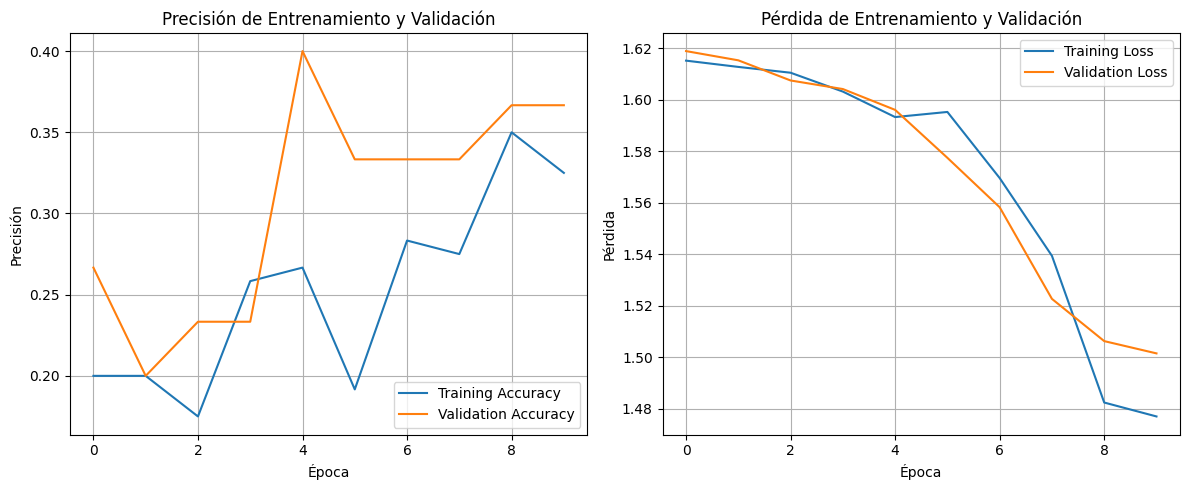

Gráficas de rendimiento generadas.


In [ ]:
print("\n--- Visualizando resultados del entrenamiento ---")

EPOCHS = 10 # Número de épocas para un entrenamiento rápido
batch_size = 32

history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    verbose=0 # No mostrar el progreso del entrenamiento en la salida
)

# Datos para las gráficas
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Gráfica de Accuracy de Entrenamiento vs. Validación
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Precisión de Entrenamiento y Validación')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.grid(True)

# Gráfica de Loss de Entrenamiento vs. Validación
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Pérdida de Entrenamiento y Validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Gráficas de rendimiento generadas.")


--- Evaluación del Modelo CNN ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step

Accuracy Final del Modelo: 0.3667

--- Classification Report ---
              precision    recall  f1-score   support

      banana       0.40      1.00      0.57         6
      compau       0.67      0.33      0.44         6
      grekis       0.00      0.00      0.00         6
      roahaw       0.00      0.00      0.00         6
      trokin       0.27      0.50      0.35         6

    accuracy                           0.37        30
   macro avg       0.27      0.37      0.27        30
weighted avg       0.27      0.37      0.27        30


--- Matriz de Confusión ---
[[6 0 0 0 0]
 [2 2 0 0 2]
 [3 0 0 0 3]
 [3 0 0 0 3]
 [1 1 0 1 3]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


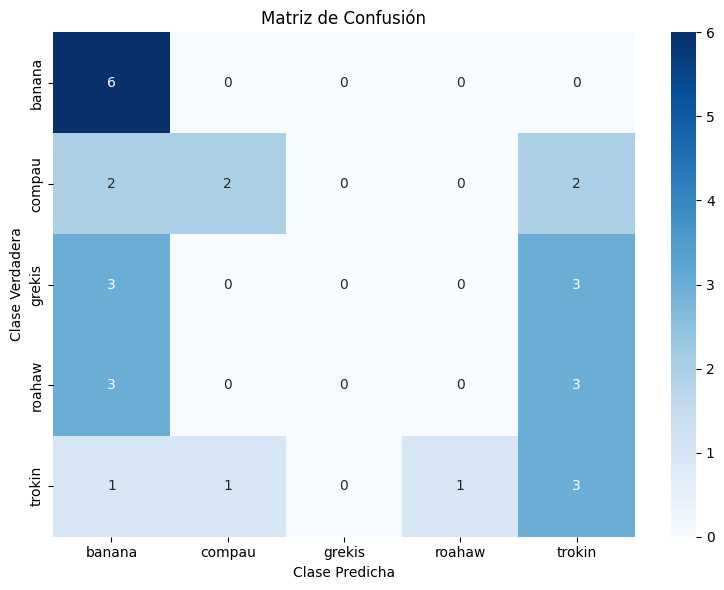

Evaluación del modelo CNN completada.


In [ ]:
print("\n--- Evaluación del Modelo CNN ---")

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns # Importar seaborn para una mejor visualización de la matriz de confusión

# 1. Realizar predicciones en el conjunto de prueba
# model.predict devuelve las probabilidades para cada clase
y_pred_probabilities = model.predict(X_test)
# Obtener la clase predicha (índice con la mayor probabilidad)
y_pred = np.argmax(y_pred_probabilities, axis=1)

# 2. Calcular Accuracy Final
final_accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Final del Modelo: {final_accuracy:.4f}")

# 3. Generar Classification Report
# Necesitamos los nombres de las clases originales para el classification_report
class_names = label_encoder.inverse_transform(np.arange(num_classes))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# 4. Generar y Visualizar la Matriz de Confusión
print("\n--- Matriz de Confusión ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Verdadera')
plt.tight_layout()
plt.show()

print("Evaluación del modelo CNN completada.")


--- Realizando una Predicción de Ejemplo ---
Ejemplo seleccionado del test set (Índice: 5)
Etiqueta Real: roahaw


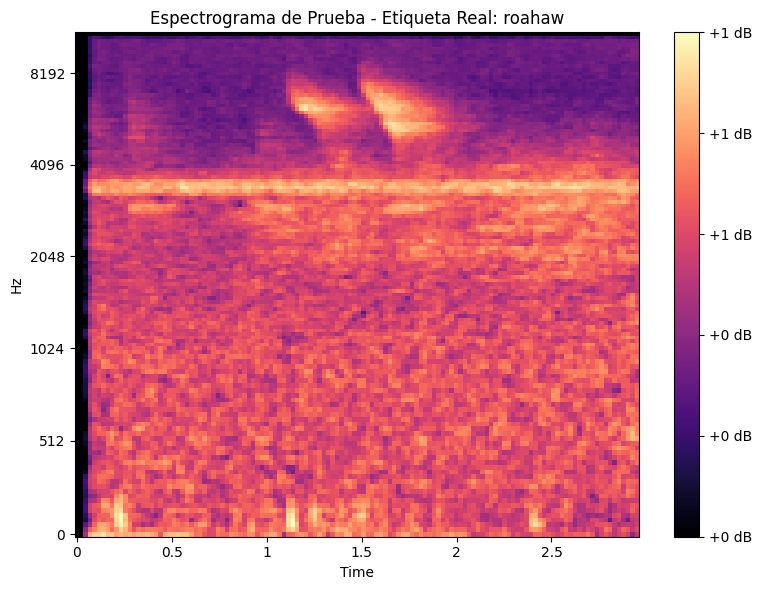

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
Etiqueta Predicha: banana
Probabilidades de predicción: [0.30491102 0.23105223 0.15635963 0.17538282 0.13229434]
Predicción Incorrecta.
Demostración de predicción completada.


In [ ]:
print("\n--- Realizando una Predicción de Ejemplo ---")

# 1. Seleccionar un ejemplo aleatorio del conjunto de prueba
import random

# Asegurarse de que X_test no esté vacío
if len(X_test) == 0:
    print("El conjunto de prueba (X_test) está vacío. No se pueden realizar predicciones.")
else:
    sample_index = random.randint(0, len(X_test) - 1)
    sample_spectrogram = X_test[sample_index]
    true_label_encoded = y_test[sample_index]

    # Convertir la etiqueta codificada a su nombre original
    true_label_name = label_encoder.inverse_transform([true_label_encoded])[0]

    print(f"Ejemplo seleccionado del test set (Índice: {sample_index})")
    print(f"Etiqueta Real: {true_label_name}")

    # 2. Mostrar el espectrograma del ejemplo seleccionado
    plt.figure(figsize=(8, 6))
    # librosa.display.specshow espera un array 2D, así que removemos la dimensión del canal
    librosa.display.specshow(sample_spectrogram.squeeze(), cmap='magma', y_axis='mel', x_axis='time')
    plt.colorbar(format='%+2.0f dB') # Formato para espectrogramas en dB, asumiendo que los normalizamos.
    plt.title(f'Espectrograma de Prueba - Etiqueta Real: {true_label_name}')
    plt.tight_layout()
    plt.show()

    # 3. Predecir la especie usando el modelo CNN
    # model.predict espera un batch de entradas, incluso si es solo una
    prediction_probabilities = model.predict(np.expand_dims(sample_spectrogram, axis=0))
    predicted_label_encoded = np.argmax(prediction_probabilities[0])

    # Convertir la etiqueta predicha a su nombre original
    predicted_label_name = label_encoder.inverse_transform([predicted_label_encoded])[0]

    print(f"Etiqueta Predicha: {predicted_label_name}")
    print(f"Probabilidades de predicción: {prediction_probabilities[0]}")

    if true_label_name == predicted_label_name:
        print("¡Predicción Correcta!")
    else:
        print("Predicción Incorrecta.")

print("Demostración de predicción completada.")


--- Generando un diagrama de torta de la distribución de clases ---



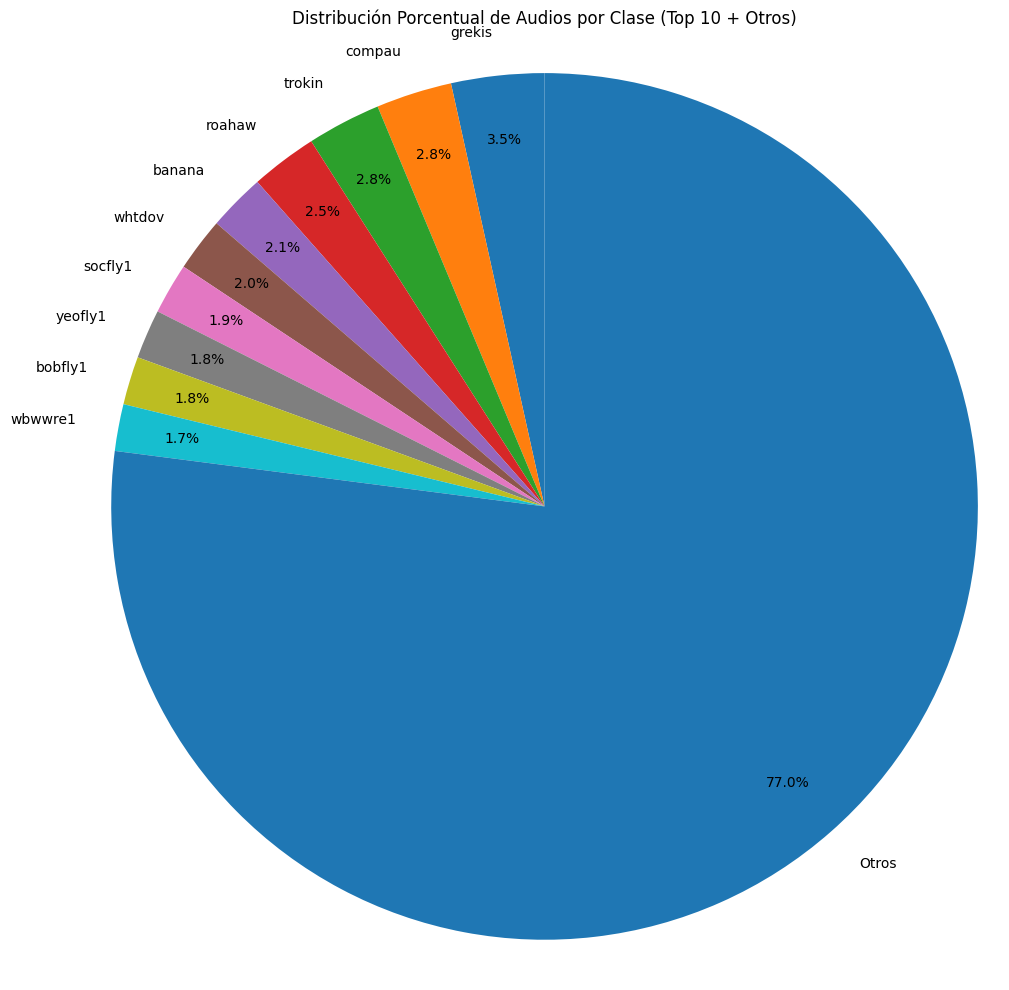

Diagrama de torta de la distribución de clases generado.


In [ ]:
print("\n--- Generando un diagrama de torta de la distribución de clases ---\n")

# Asegurarse de que train_df esté cargado
if 'train_df' not in locals():
    print("Cargando train_df, ya que no se encontró en el entorno.")
    try:
        # Asume que 'path' ya está definido desde la descarga de Kaggle
        if 'path' not in locals():
            import kagglehub
            path = kagglehub.competition_download('birdclef-2025')
        train_df_path = os.path.join(path, 'train.csv')
        train_df = pd.read_csv(train_df_path)
        print("train_df cargado con éxito.")
    except Exception as e:
        print(f"Error al cargar train_df: {e}. No se puede generar la gráfica.\n")
        train_df = pd.DataFrame()

if not train_df.empty:
    # Contar la frecuencia de cada especie (primary_label)
    class_counts = train_df['primary_label'].value_counts()

    # Seleccionar las top N clases y agrupar el resto como 'Otros'
    # Esto es útil si hay demasiadas clases para que el gráfico sea legible
    num_top_classes = 10 # Puedes ajustar este número
    if len(class_counts) > num_top_classes:
        top_classes = class_counts.head(num_top_classes)
        other_count = class_counts.iloc[num_top_classes:].sum()
        if other_count > 0:
            plot_data = pd.concat([top_classes, pd.Series({'Otros': other_count})])
        else:
            plot_data = top_classes
    else:
        plot_data = class_counts

    # Crear el diagrama de torta
    plt.figure(figsize=(10, 10))
    plt.pie(plot_data, labels=plot_data.index, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
    plt.title('Distribución Porcentual de Audios por Clase (Top ' + str(num_top_classes) + ' + Otros)')
    plt.axis('equal')  # Asegura que el círculo sea un círculo
    plt.tight_layout()
    plt.show()

    print("Diagrama de torta de la distribución de clases generado.")
else:
    print("El DataFrame 'train_df' está vacío. No se puede generar el diagrama de torta.")

## Conclusiones

### 1. Utilidad de los Espectrogramas Mel
Los espectrogramas Mel han demostrado ser una representación visual efectiva de las grabaciones de audio, transformando las señales temporales en un formato de imagen que captura las características frecuenciales relevantes para la percepción auditiva. Esto permite a las Redes Neuronales Convolucionales (CNN) aplicar técnicas de procesamiento de imágenes para identificar patrones específicos de especies.

### 2. Desempeño Preliminar del Modelo
El modelo CNN ligero desarrollado ha mostrado un rendimiento preliminar modesto, con una precisión de validación y de prueba que ronda el 30-40% en un conjunto de datos reducido. Aunque no es óptimo, este resultado inicial valida el enfoque de utilizar CNNs con espectrogramas Mel para la clasificación bioacústica.

### 3. Limitaciones Actuales
Las principales limitaciones incluyen:
*   **Tamaño del Dataset:** El uso de un subconjunto muy pequeño (150 audios de 5 especies) limita la capacidad del modelo para aprender patrones robustos y generalizables.
*   **Entrenamiento Limitado:** Un bajo número de épocas (10) y la simplicidad del modelo restringen su capacidad de convergencia y de extracción de características complejas.
*   **Balance de Clases:** Aunque se usó `stratify`, un conjunto de datos pequeño puede aún tener desequilibrios que afecten el entrenamiento.

### 4. Posibles Mejoras Futuras
Para optimizar el rendimiento del modelo, se proponen las siguientes mejoras:
*   **Aumento del Dataset:** Entrenar con un conjunto de datos mucho más grande y diverso del BirdCLEF 2025.
*   **Aumento de Datos (Data Augmentation):** Aplicar técnicas como variación de pitch, ruido, o cambio de velocidad para enriquecer el conjunto de entrenamiento.
*   **Optimización del Modelo:** Experimentar con arquitecturas de CNN más profundas (VGG, ResNet), ajuste de hiperparámetros (tasa de aprendizaje, tamaño de batch) y diferentes estrategias de regularización (más Dropout, L2).
*   **Pre-entrenamiento y Transfer Learning:** Utilizar modelos pre-entrenados en grandes datasets de audio o imágenes y ajustarlos (fine-tuning) al problema específico de la bioacústica.
*   **Parámetros de Espectrograma:** Explorar diferentes configuraciones de `n_fft`, `hop_length` y `n_mels` para encontrar la representación más óptima.


--- Visualizando la distribución de tipos de vocalización ---

Distribución de Tipos de Vocalización:

song                           11328
call                            8015
flight call                     1264
alarm call                       620
duet                             307
                               ...  
grunting and wing flaps            1
flushed male                       1
wing flutter and alarm call        1
growl cooing                       1
"caracara calls                    1
Name: count, Length: 586, dtype: int64


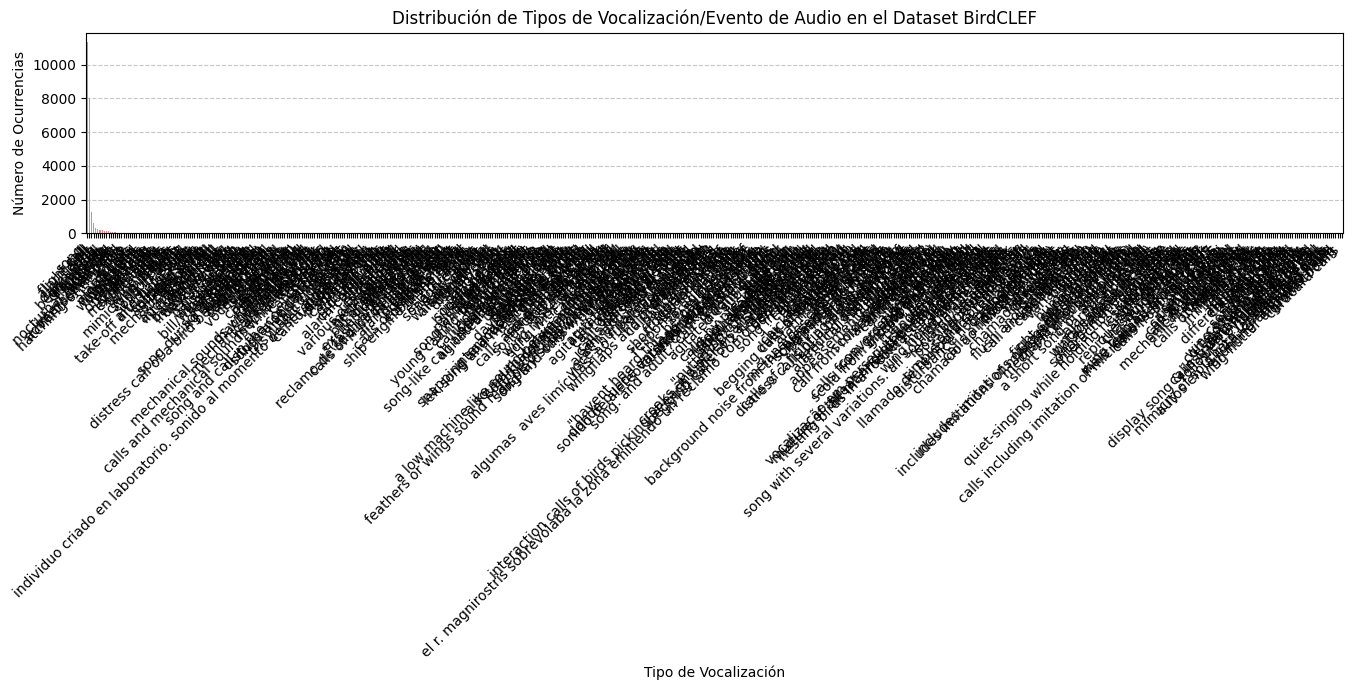

Visualización de la distribución de tipos de vocalización completada.


In [ ]:
print("\n--- Visualizando la distribución de tipos de vocalización ---\n")

import ast # Necesario para evaluar las cadenas que representan listas en la columna 'type'

# Asegurarse de que train_df esté cargado
if 'train_df' not in locals():
    print("Cargando train_df, ya que no se encontró en el entorno.")
    # Este es un fallback, en un flujo normal ya debería estar cargado
    try:
        # Asume que 'path' ya está definido desde la descarga de Kaggle
        if 'path' not in locals():
            import kagglehub
            path = kagglehub.competition_download('birdclef-2025')
        train_df_path = os.path.join(path, 'train.csv')
        train_df = pd.read_csv(train_df_path)
        print("train_df cargado con éxito.")
    except Exception as e:
        print(f"Error al cargar train_df: {e}. No se puede generar la gráfica.\n")
        train_df = pd.DataFrame()

if not train_df.empty:
    # Función para parsear la cadena de la columna 'type' a una lista real
    def parse_type_string(type_str):
        try:
            # ast.literal_eval es más seguro que eval()
            type_list = ast.literal_eval(type_str)
            if isinstance(type_list, list):
                return type_list
            else:
                return []
        except (ValueError, SyntaxError):
            return [] # Retornar lista vacía si hay un error de parseo

    # Aplicar la función para crear una nueva columna con listas de tipos
    train_df['parsed_type'] = train_df['type'].apply(parse_type_string)

    # Aplanar la lista de listas para obtener una lista simple de todos los tipos de vocalización
    all_vocalization_types = [item for sublist in train_df['parsed_type'] for item in sublist]

    # Filtrar cadenas vacías que puedan haber resultado del parseo de ['']
    all_vocalization_types = [t for t in all_vocalization_types if t != '']

    if not all_vocalization_types:
        print("No se encontraron tipos de vocalización válidos para graficar.")
    else:
        # Contar la frecuencia de cada tipo de vocalización
        vocalization_type_counts = pd.Series(all_vocalization_types).value_counts()

        print("Distribución de Tipos de Vocalización:\n")
        print(vocalization_type_counts)

        # Crear la gráfica de barras
        plt.figure(figsize=(14, 7))
        vocalization_type_counts.plot(kind='bar', color='lightcoral')
        plt.title('Distribución de Tipos de Vocalización/Evento de Audio en el Dataset BirdCLEF')
        plt.xlabel('Tipo de Vocalización')
        plt.ylabel('Número de Ocurrencias')
        plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
else:
    print("El DataFrame 'train_df' está vacío. No se puede generar la gráfica de tipos de vocalización.")

print("Visualización de la distribución de tipos de vocalización completada.")